In [41]:
import sys
import numpy as np
sys.path.append(r'../src')
from utils.stock_simulation import *
from utils.market_simulator import *
SEED = 52

### Market B

/Users/edouardblanc/Desktop/cours_203_m2/S2/electronic_trading/projet_market_making/test/../src/utils/market_simulator/market.py:359: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/edouardblanc/Desktop/cours_203_m2/S2/electronic_trading/projet_market_making/market_making/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


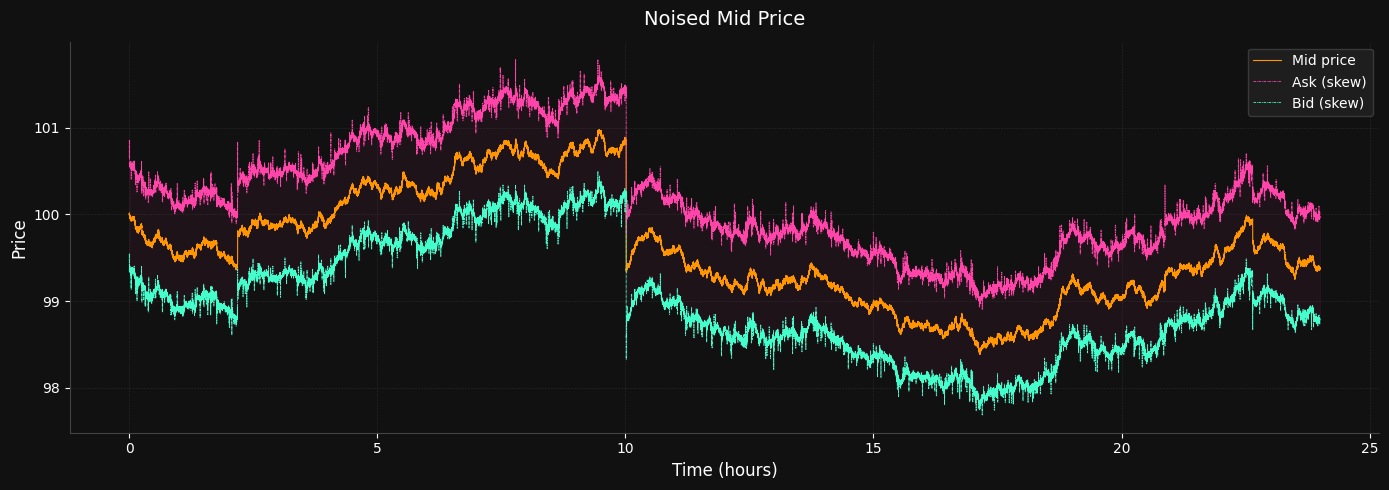

────────────────────────────────────────────────────────────────────────────
Metric                                               Skewed
────────────────────────────────────────────────────────────────────────────
Spread mean (price units)                            1.1943
Spread std  (price units)                            0.0341
Spread min  (price units)                            1.1063
Spread max  (price units)                            1.5980
Relative spread mean (%)                           1.1991%
Relative spread std  (%)                           0.0336%
Ask bias vs mid (mean)                               0.5971
Bid bias vs mid (mean)                               0.5971
Ask vol (ann., log-ret)                           75.3906%
Bid vol (ann., log-ret)                           77.5593%
Quote center offset (mean)                          -0.0000
Ask half − Bid half (mean)                          -0.0000
──────────────────────────────────────────────────────────────────────

In [42]:
np.random.seed(SEED)
WINDOW_SIZE = 600
USE_JUMPS = True
drift = 0
vol = 0.2
stock_garch = Stock(drift=0.0, vol=0.20)
stock_garch.simulate_garch( n_days=1, dt_seconds=0.01, alpha=0.05, beta=0.94, lam=756 if USE_JUMPS else 0.0, sigma_J=0.005 if USE_JUMPS else 0.0,
)
market_B = Market(stock=stock_garch)
market_B.generate_noised_mid_price()
market_B.build_spread(option="Skew", window_size=WINDOW_SIZE, alpha=0.5, gamma=0.3, ema_span=500, threshold=3)
market_B.plot_noised_mid_price(["Skew"])
market_B.sanity_check_spreads()

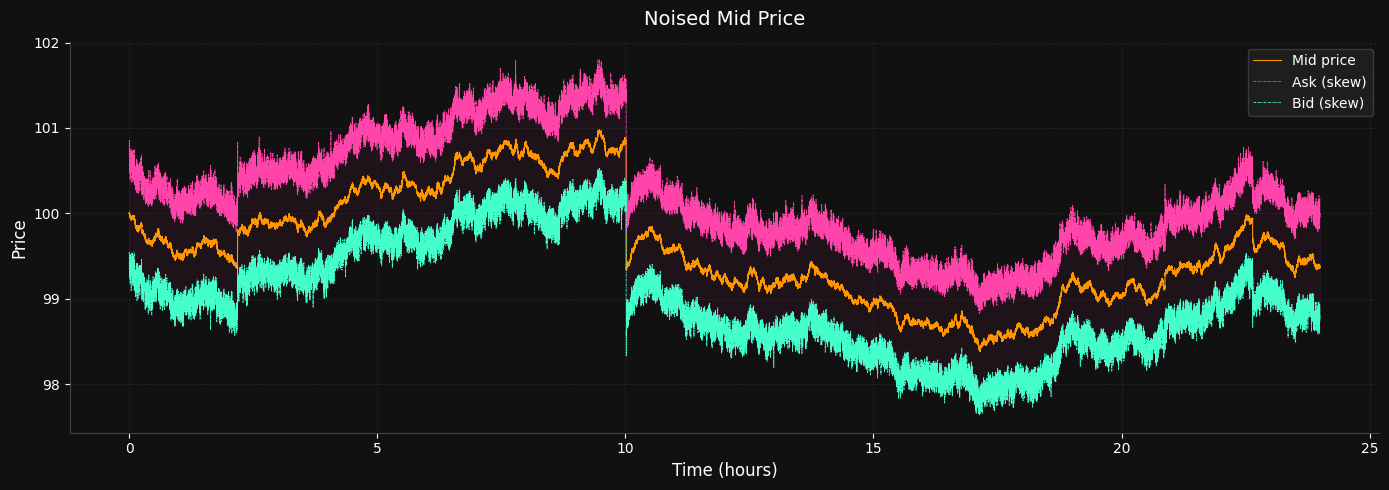

In [43]:
import copy
market_C = copy.deepcopy(market_B)
market_C.build_spread(option = "Skew")
market_C.plot_noised_mid_price(["Skew"])


### Order Book

In [44]:
import utils.order_book.order_book_impl as book_utils
Order_book = book_utils.Order_book()

### Market Maker

In [45]:
import utils.market_maker.quoter as quoter_utils
from utils.market_maker.quoter        import Quoter, QuoterConfig

cfg = QuoterConfig(requote_threshold_spread_fraction=0)   # all defaults — see quoter.py for parameter meaning

market_maker_A  =  Quoter(market_B, market_C, config=cfg, capital_K=1_000_000.0)
Order_book.register_quoter_listener(market_maker_A.on_fill)
a = market_maker_A.compute_quotes(step=0, t=1*stock_garch.time_step, resting_orders = Order_book.mm_resting_orders)
a


([<utils.order_book.order_book_impl.Order at 0x12fdd7800>,
 [])

### Order generation

Adding orders: 100%|██████████| 10/10 [00:00<00:00, 1533.29it/s]


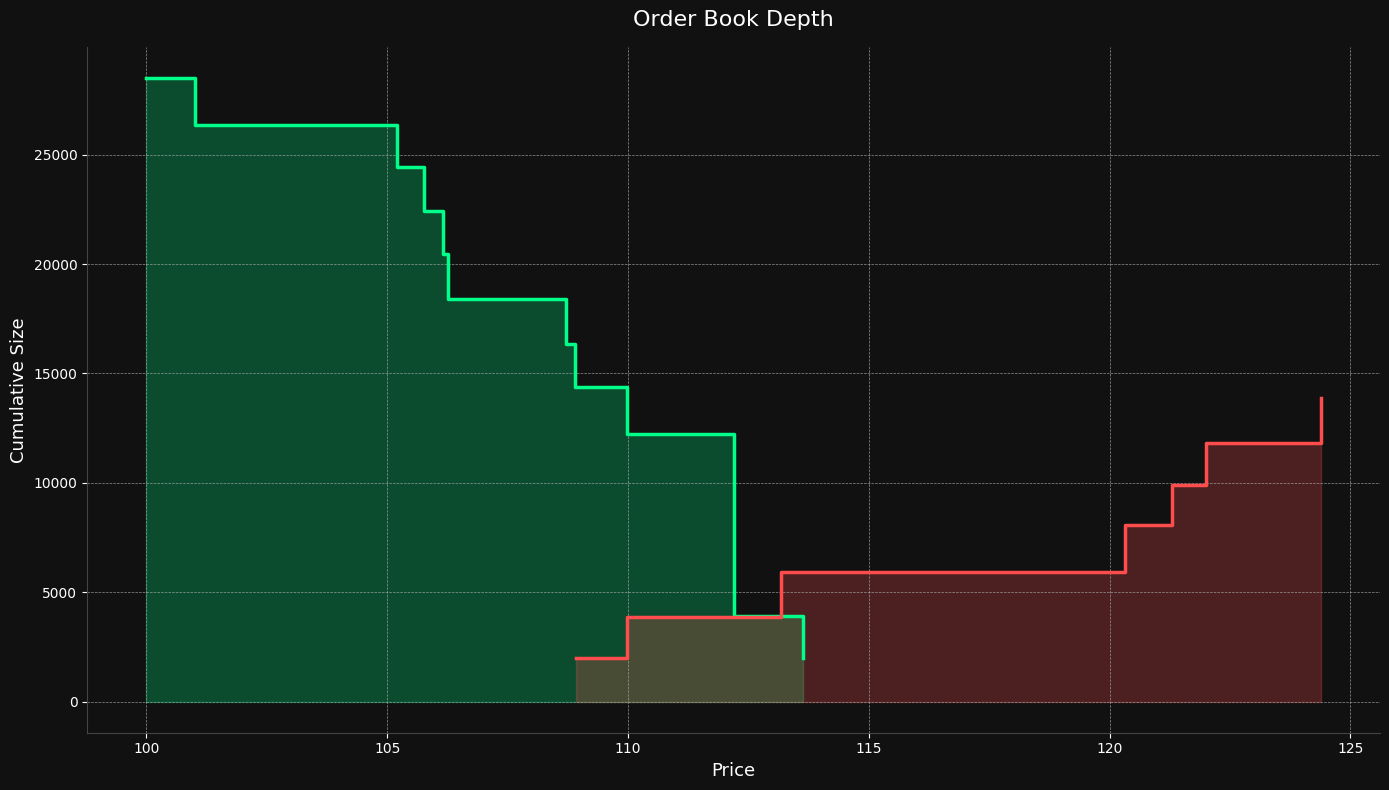

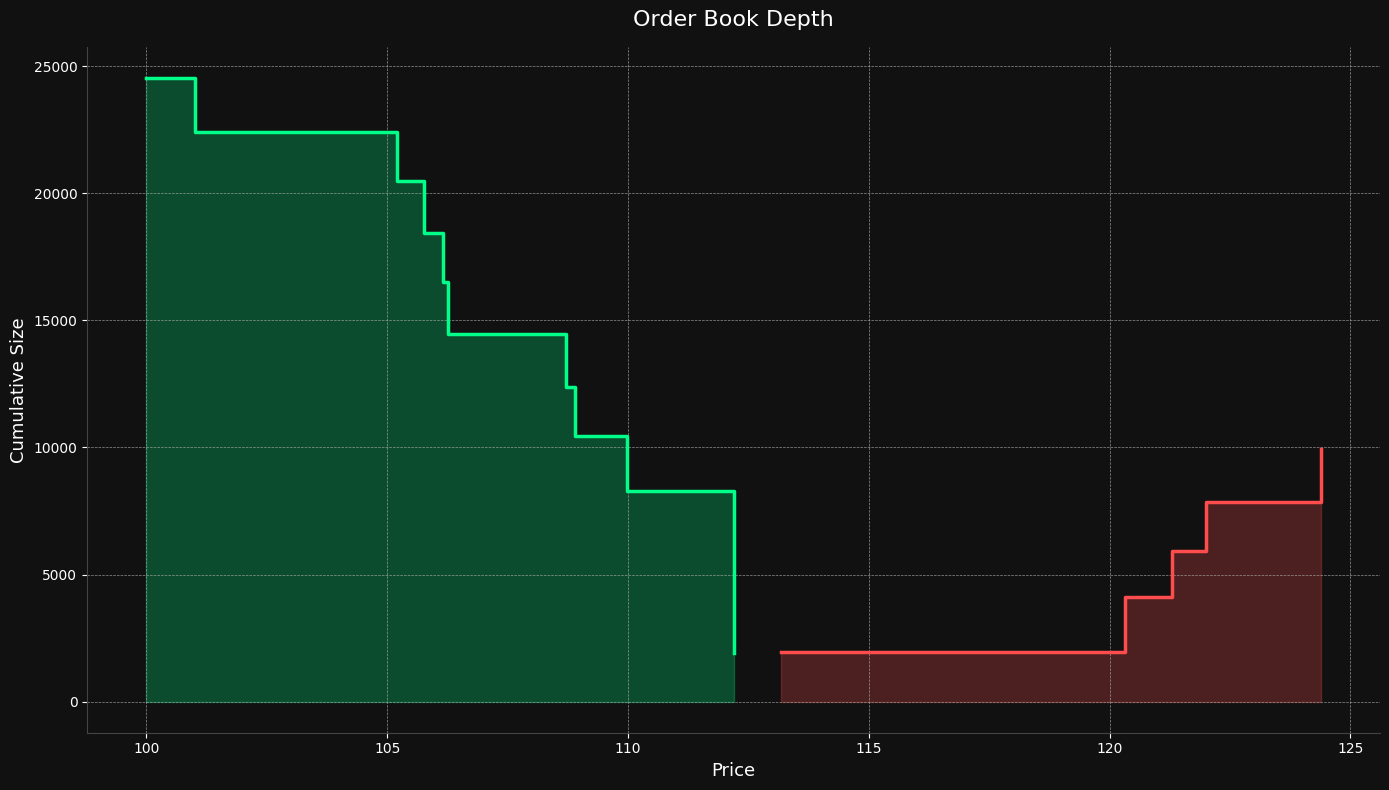

In [46]:
import utils.order_book.order_book_impl as book_utils
import utils.order_book.graphic_utils as graph_utils
Order_book._generate_n_random_order(10)


client_order = Order_book.generate_random_orders(10, origin = "client")
Order_book._add_orders_batch(client_order)
graph_utils.plot_order_book(Order_book)
Order_book.try_clear()
graph_utils.plot_order_book(Order_book)

In [47]:
from utils.client_flow.flow_generator import ClientFlowGenerator

In [48]:
#ask = market_B.ask_price_skewed[0]
#bid = market_B.bid_price_skewed[0]
ask = 120
bid = 120 - 1
fair = (ask + bid)/2

gen = ClientFlowGenerator()

orders = gen.generate_step(mid_price=fair, best_bid= bid, best_ask=ask, dt = 0.01)
Order_book._add_orders_batch(orders)

Adding orders: 100%|██████████| 8/8 [00:00<00:00, 1346.32it/s]


In [49]:
Order_book.try_clear()

In [50]:
Order_book._df_matches

,MatchId,ClientOrderId,MmOrderId,Direction,Price,MatchedSize,Time
0,1776287125381_7894,1776287125066_4415,1776287125027_1026,buy,109.9882,1893,2026-04-15 23:05:25.381
1,1776287125382_8864,1776287125066_4415,1776287125049_5488,buy,113.1871,95,2026-04-15 23:05:25.382
2,1776287125388_5818,1776287125070_1536,1776287125051_7880,sell,109.9881,1971,2026-04-15 23:05:25.388
3,1776287125485_6203,1776287125466_7626,1776287125049_5488,buy,113.1871,1383,2026-04-15 23:05:25.485
4,1776287125487_8331,1776287125466_9143,1776287125049_5488,buy,113.1871,584,2026-04-15 23:05:25.487


In [52]:
market_maker_A._fill_history

[{'step': 0,
  'direction': 'sell',
  'price': np.float64(109.9882),
  'size': np.int64(1893),
  'is_full_fill': True},
 {'step': 0,
  'direction': 'sell',
  'price': np.float64(113.1871),
  'size': np.int64(584),
  'is_full_fill': True}]